# **BÀI THỰC HÀNH 9: SCIKIT-LEARN VÀ HỒI QUY**

Sinh viên thực hiện: Võ Bạch Kim Thịnh

Mã số sinh viên: 2045230096

## **9.1. Giới thiệu Scikit-Learn**
Scikit-learn cung cấp rất nhiều mô hình khác nhau để thực hiện các bài toán như hồi
quy, phân loại và nhiều kỹ thuật máy học khác. Điểm thuận tiện là các mô hình này có
cú pháp sử dụng nhất quán, giúp người học và người phát triển dễ dàng tiếp cận và triển
khai.
Một trong những mô hình cơ bản và được sử dụng phổ biến là hồi quy tuyến tính
(Linear Regression). Đây là mô hình dùng để dự đoán giá trị liên tục bằng cách thiết lập
mối quan hệ tuyến tính giữa biến đầu vào và biến đầu ra. Nhờ tính đơn giản, dễ hiểu và
dễ triển khai, hồi quy tuyến tính thường được sử dụng như một bước khởi đầu trong các
bài toán hồi quy.
Bạn đã biết đến khái niệm huấn luyện một thuật toán trên dữ liệu, và có thể sử dụng
mô hình được huấn luyện này để đưa ra dự đoán trên dữ liệu mới. Scikit-learn gói gọn
các chức năng cốt lõi này trong phương thức .fit cho các mô hình huấn luyện và phương
pháp .predict để đưa ra dự đoán. Do cú pháp nhất quán, bạn có thể gọi .fit và .predict
trên bất kỳ mô hình scikit-learn nào từ hồi quy tuyến tính đến cây phân loại.

## **9.2. Minh họa hồi quy logistic với Scikit-Learn**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Thiết lập hiển thị đồ thị
%matplotlib inline
mpl.rcParams['figure.dpi'] = 100
plt.style.use('seaborn-v0_8-whitegrid')

from sklearn.linear_model import LogisticRegression

In [ ]:
my_lr = LogisticRegression()

print("Các tùy chọn mặc định của mô hình:")
display(my_lr.get_params())

Các tùy chọn mặc định của mô hình:


{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [ ]:
my_new_lr = LogisticRegression()
my_new_lr.C = 0.1
my_new_lr.solver = 'liblinear'
my_new_lr.multi_class = 'auto'

print("Mô hình sau khi cập nhật tham số:")
my_new_lr

Mô hình sau khi cập nhật tham số:


LogisticRegression(C=0.1, multi_class='auto', solver='liblinear')

C = 0.1: Tham số C là nghịch đảo của hệ số điều chuẩn (Regularization strength). Giá trị mặc định là 1.0. Khi giảm xuống 0.1, ta đang yêu cầu mô hình "phạt" mạnh hơn các hệ số trọng lượng quá lớn, giúp mô hình đơn giản hơn và tránh hiện tượng quá khớp (overfitting).

solver = 'liblinear': Đây là thuật toán tối ưu hóa để tìm ra các hệ số hồi quy. liblinear là bộ giải cực kỳ hiệu quả và phù hợp với các tập dữ liệu nhỏ hoặc bài toán phân loại nhị phân.

multi_class = 'auto': Cho phép mô hình tự động chọn chiến lược phân loại nhiều lớp (ví dụ: OvR - One vs Rest) dựa trên dữ liệu đầu vào.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Load lại dữ liệu
df = pd.read_csv('/content/drive/MyDrive/credit_card_clean_3.csv')

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,EDUCATION_CAT,graduate school,high school,others,university
0,798fc410-45c1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,1,university,False,False,False,True
1,8a8c8f3b-8eb4,120000,2,2,2,26,-1,2,0,0,...,1000,1000,0,2000,1,university,False,False,False,True
2,85698822-43f5,90000,2,2,2,34,0,0,0,0,...,1000,1000,1000,5000,0,university,False,False,False,True
3,0737c11b-be42,50000,2,2,1,37,0,0,0,0,...,1200,1100,1069,1000,0,university,False,False,False,True
4,3b7f77cc-dbc0,50000,1,2,1,57,-1,0,-1,0,...,10000,9000,689,679,0,university,False,False,False,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26664 entries, 0 to 26663
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ID                          26664 non-null  object
 1   LIMIT_BAL                   26664 non-null  int64 
 2   SEX                         26664 non-null  int64 
 3   EDUCATION                   26664 non-null  int64 
 4   MARRIAGE                    26664 non-null  int64 
 5   AGE                         26664 non-null  int64 
 6   PAY_1                       26664 non-null  int64 
 7   PAY_2                       26664 non-null  int64 
 8   PAY_3                       26664 non-null  int64 
 9   PAY_4                       26664 non-null  int64 
 10  PAY_5                       26664 non-null  int64 
 11  PAY_6                       26664 non-null  int64 
 12  BILL_AMT1                   26664 non-null  int64 
 13  BILL_AMT2                   26664 non-null  in

In [ ]:
df.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,26664.000000,26664.000000,26664.000000,26664.000000,26664.000000,26664.000000,26664.000000,26664.000000,26664.000000,26664.000000,...,26664.000000,26664.000000,26664.000000,26664.000000,2.666400e+04,26664.000000,26664.000000,26664.000000,26664.000000,26664.000000
mean,167919.054905,1.603060,1.842334,1.556031,35.505213,-0.017777,-0.133363,-0.167679,-0.225023,-0.269764,...,43338.894539,40338.136701,38889.872337,5704.085771,5.881110e+03,5259.514964,4887.048717,4843.729973,5257.843047,0.221797
std,129839.453081,0.489272,0.744661,0.521463,9.227442,1.126769,1.198640,1.199165,1.167897,1.131735,...,64275.250740,60705.944083,59432.541657,16699.398632,2.121431e+04,17265.439561,15956.349371,15311.721795,17635.468185,0.415463
min,10000.000000,1.000000,1.000000,1.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2341.750000,1745.000000,1256.000000,1000.000000,8.020000e+02,390.000000,294.750000,242.750000,111.000000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19037.000000,18066.000000,17005.000000,2114.500000,2.007000e+03,1822.000000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54727.500000,50290.500000,49253.750000,5027.000000,5.000000e+03,4556.250000,4050.500000,4082.750000,4015.000000,0.000000
max,800000.000000,2.000000,4.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,706864.000000,823540.000000,699944.000000,873552.000000,1.227082e+06,889043.000000,621000.000000,426529.000000,528666.000000,1.000000


In [ ]:
# Kiểm tra biến phản hồi để xem tỷ lệ mặc nợ
mean_default = df['default payment next month'].mean()
print(f"Tỷ lệ nhãn bằng 1 (mặc định): {mean_default}")

# Xem số lượng cụ thể của từng nhóm
count_default = df.groupby('default payment next month')['ID'].count()
display(count_default)

Tỷ lệ nhãn bằng 1 (mặc định): 0.2217971797179718


,ID
default payment next month,
0,20750
1,5914


In [ ]:
# Mượn 10 giá trị thuộc tính EDUCATION làm biến X và thay đổi thành dạng cột
X = df['EDUCATION'][0:10].values.reshape(-1, 1)

# Mượn 10 giá trị tương ứng của biến phản hồi làm biến y
y = df['default payment next month'][0:10].values

# Thực hiện mô hình hồi quy logistic
my_new_lr.fit(X, y)

print(f"Huấn luyện xong!\nHệ số góc: {my_new_lr.coef_}, \nHệ số chặn: {my_new_lr.intercept_}")

Huấn luyện xong!
Hệ số góc: [[-0.25972953]], 
Hệ số chặn: [-0.14148497]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
# Lấy 10 giá trị tiếp theo làm dữ liệu mới
new_X = df['EDUCATION'][10:20].values.reshape(-1, 1)
actual_y = df['default payment next month'][10:20].values

# Thực hiện dự đoán
predictions = my_new_lr.predict(new_X)

# So sánh với giá trị thực tế bằng cách tạo DataFrame trực quan
comparison_df = pd.DataFrame({
    'Giá trị X (EDUCATION)': new_X.flatten(),
    'Dự đoán của mô hình': predictions,
    'Giá trị thực tế': actual_y
})
display(comparison_df)

# Đánh giá độ chính xác "bằng tay"
accuracy = np.mean(predictions == actual_y)
print(f"\nĐộ chính xác trên 10 mẫu kiểm tra: {accuracy * 100}%")

,Giá trị X (EDUCATION),Dự đoán của mô hình,Giá trị thực tế
0,3,0,0
1,1,0,0
2,2,0,0
3,2,0,1
4,1,0,0
5,3,0,0
6,1,0,1
7,1,0,0
8,1,0,0
9,3,0,0



Độ chính xác trên 10 mẫu kiểm tra: 80.0%


9.3. Tạo dữ liệu tổng hợp để thực hiện hồi quy tuyến tính
Phân tích tham số theo mã số sinh viên (2045230096):

* $a$: Số thứ 8 của MSSV là 0 $\rightarrow$
Kết quả chia 4 là 0 nên lấy giá trị $a = 0.25$.

* $b$: 2 số cuối MSSV là 96 $\rightarrow$ $96 / 10 = 9.6$. Chữ số cuối cùng là số chẵn (6), nên $b$ giữ nguyên dấu dương $\rightarrow$ $b = 9.6$.

10 giá trị đầu tiên của X:
[[7.73717756]
 [4.76870423]
 [5.31387258]
 [4.55002308]
 [5.9273561 ]
 [2.97880254]
 [7.44220224]
 [7.06448483]
 [7.33601707]
 [4.60409385]]


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7871 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7891 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND GRAVE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7883 (\N{LATIN SMALL LETTER I WITH DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7911 (\N{LATIN SMALL LETTER U WITH HOOK ABOVE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7919 (\N{LATIN

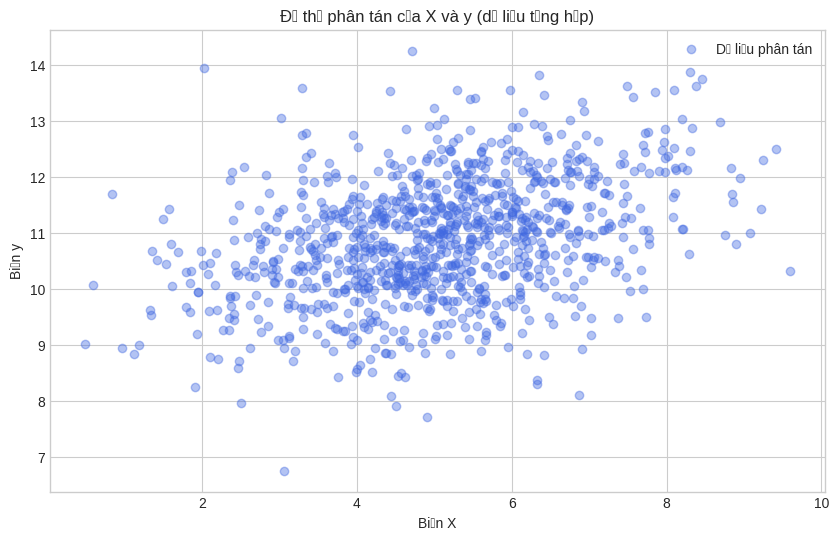

In [ ]:
from sklearn.linear_model import LinearRegression

X_gen = np.random.normal(5, 1.5, 1000).reshape(-1, 1)

print("10 giá trị đầu tiên của X:")
print(X_gen[:10])

# 2. Tạo array y theo công thức y = aX + b + N(0,1)
a = 0.25
b = 9.6
noise = np.random.normal(0, 1, 1000).reshape(-1, 1)
y_gen = a * X_gen + b + noise

# 3. Vẽ đồ thị phân tán
plt.figure(figsize=(10, 6))
plt.scatter(X_gen, y_gen, color='royalblue', alpha=0.4, label='Dữ liệu phân tán')
plt.title('Đồ thị phân tán của X và y (dữ liệu tổng hợp)')
plt.xlabel('Biến X')
plt.ylabel('Biến y')
plt.legend()
plt.show()

In [ ]:
lr_sklearn = LinearRegression()
lr_sklearn.fit(X_gen, y_gen)
a_sk = lr_sklearn.coef_[0][0]
b_sk = lr_sklearn.intercept_[0]

X_b = np.c_[np.ones((1000, 1)), X_gen]
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_gen)
b_theory, a_theory = theta_best[0][0], theta_best[1][0]

# In và so sánh kết quả
print(f"Tham số hàm gốc  : a = {a}, b = {b}")
print(f"Bằng Scikit-Learn: a = {a_sk:.4f}, b = {b_sk:.4f}")
print(f"Bằng Lý thuyết   : a = {a_theory:.4f}, b = {b_theory:.4f}")

Tham số hàm gốc  : a = 0.25, b = 9.6
Bằng Scikit-Learn: a = 0.2591, b = 9.5684
Bằng Lý thuyết   : a = 0.2591, b = 9.5684


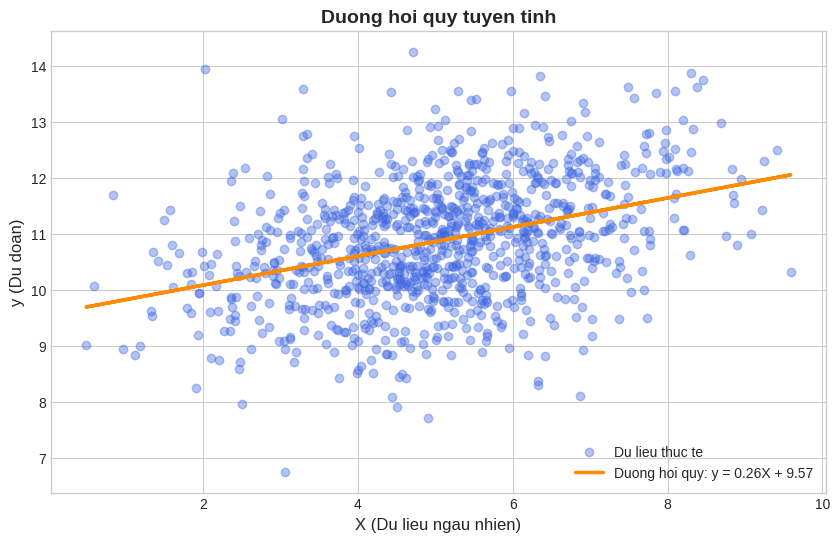

In [ ]:
y_pre = lr_sklearn.predict(X_gen)

plt.figure(figsize=(10, 6))
plt.scatter(X_gen, y_gen, color='royalblue', alpha=0.4, label='Du lieu thuc te')
plt.plot(X_gen, y_pre, color='darkorange', linewidth=2.5, label=f'Duong hoi quy: y = {a_sk:.2f}X + {b_sk:.2f}')
plt.title('Duong hoi quy tuyen tinh', fontsize=14, fontweight='bold')
plt.xlabel('X (Du lieu ngau nhien)', fontsize=12)
plt.ylabel('y (Du doan)', fontsize=12)
plt.legend()
plt.show()

Hai phương pháp (lý thuyết Đại số tuyến tính và thư viện Scikit-Learn) trả ra kết quả hoàn toàn giống nhau đến từng chữ số thập phân. Điều này chứng minh rằng hàm `.fit()` của thư viện bản chất là việc thực thi các tính toán tối ưu toán học.

Hệ số góc (a) và hệ số chặn (b) thu được từ mô hình dự đoán rất bám sát với giá trị tham số khởi tạo ban đầu ($a=0.25$, $b=9.6$). Sự chênh lệch rất nhỏ (chỉ vài phần trăm) xuất hiện là do thuộc tính nhiễu phân phối chuẩn $\mathcal{N}(0, 1)$ mà ta đã chủ động thêm vào tập dữ liệu.

Đường hồi quy được mô hình vẽ ra là quỹ đạo đi qua trung tâm mật độ phân bổ của đám mây điểm dữ liệu, cho thấy phương pháp Linear Regression đã thành công trong việc nắm bắt xu hướng tuyến tính giữa X và y.